# Notebook 8 — Economic–Ecological Risk Overlap Analysis

This notebook uses the ecological proxy dataset created in Notebook 7 and analyzes the overlap between predicted monetary wildfire risk and ecological exposure.

It produces quadrant-based outputs useful for a short thesis subsection:

- high economic risk + high ecological exposure,
- high economic risk + lower ecological exposure,
- lower economic risk + high ecological exposure,
- lower economic risk + lower ecological exposure.


In [1]:

# ============================================================
# Cell 1 — Imports and export setup
# ============================================================
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

EXPORT_DIR = Path("/content/thesis_exports/notebook8_economic_ecological_overlap_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:", EXPORT_DIR)


Export directory: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles


In [2]:

# ============================================================
# Cell 2 — Helper functions for clean no-title exports
# ============================================================

def _format_value(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return f"{x:,}"
    if isinstance(x, (float, np.floating)):
        ax = abs(x)
        if ax >= 1_000_000:
            return f"{x:,.0f}"
        if ax >= 1_000:
            return f"{x:,.2f}"
        if ax >= 10:
            return f"{x:,.2f}"
        return f"{x:,.4f}"
    return str(x)


def save_dataframe_as_pdf_no_title(df, filename, rows_per_page=25, fontsize=7, fig_width=14, row_height=0.38):
    path = EXPORT_DIR / filename
    df_to_save = df.copy()
    for col in df_to_save.columns:
        df_to_save[col] = df_to_save[col].apply(_format_value)

    with PdfPages(path) as pdf:
        for start in range(0, len(df_to_save), rows_per_page):
            page_df = df_to_save.iloc[start:start + rows_per_page]
            fig_height = max(4.0, row_height * len(page_df) + 1.2)
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")
            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                loc="center"
            )
            table.auto_set_font_size(False)
            table.set_fontsize(fontsize)
            table.scale(1, 1.25)
            for key, cell in table.get_celld().items():
                cell.set_linewidth(0.4)
                if key[0] == 0:
                    cell.set_text_props(weight="bold")
                    cell.set_facecolor("#eeeeee")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    print("Saved table PDF:", path)
    return path


def save_current_figure(fig, pdf_name, png_name=None, dpi=300):
    pdf_path = EXPORT_DIR / pdf_name
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved figure PDF:", pdf_path)
    if png_name is not None:
        png_path = EXPORT_DIR / png_name
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
        print("Saved figure PNG:", png_path)
    return pdf_path


In [3]:

# ============================================================
# Cell 3 — Load Notebook 7 ecological proxy output
# ============================================================
# Preferred: run Notebook 7 first. Then this path should exist.
# If needed, set DATA_PATH manually.
DATA_PATH = "/content/county_ecological_risk_proxy_full.csv"
DATA_PATH = None

candidate_paths = []
if DATA_PATH is not None:
    candidate_paths = [Path(DATA_PATH)]
else:
    candidate_paths = [
        Path("/content/thesis_exports/notebook7_ecological_proxy_no_titles/county_ecological_risk_proxy_full.csv")
    ]
    for root in [Path("/content"), Path("/content/thesis_exports")]:
        if root.exists():
            candidate_paths.extend(root.rglob("*ecological*risk*proxy*full*.csv"))

candidate_paths = list(dict.fromkeys(candidate_paths))
print("Candidate files:")
for p in candidate_paths:
    print(p)

risk_df = None
selected_path = None
required_cols = {
    "state", "county", "county_fips", "predicted_wildfire_eal",
    "predicted_risk_percentile", "natural_vegetation_fraction", "ecological_risk_proxy"
}

for p in candidate_paths:
    if p.exists():
        temp = pd.read_csv(p)
        if required_cols.issubset(set(temp.columns)):
            risk_df = temp.copy()
            selected_path = p
            break

if risk_df is None:
    raise ValueError("Could not find Notebook 7 output. Please run Notebook 7 first or set DATA_PATH manually.")

print("Selected file:", selected_path)
print("Shape:", risk_df.shape)
display(risk_df.head())


Candidate files:
/content/thesis_exports/notebook7_ecological_proxy_no_titles/county_ecological_risk_proxy_full.csv
/content/county_ecological_risk_proxy_full.csv
Selected file: /content/county_ecological_risk_proxy_full.csv
Shape: (3163, 39)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,...,predicted_risk_percentile,predicted_risk_category,forest_fraction_01,shrub_fraction_01,grass_fraction_01,developed_fraction_01,natural_vegetation_fraction,ecological_risk_proxy,ecological_risk_percentile,ecological_risk_category
0,Alabama,Autauga,1001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,...,51.944357,Moderate,0.498794,0.069525,0.210785,0.064990,0.779104,40.470041,68.131521,High
1,Alabama,Baldwin,1003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,...,91.811571,Very High,0.269194,0.037410,0.088107,0.071507,0.394711,36.238999,64.653810,High
2,Alabama,Barbour,1005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,...,43.534619,Moderate,0.565439,0.104817,0.129400,0.040160,0.799656,34.812708,63.199494,High
3,Alabama,Bibb,1007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,...,43.661081,Moderate,0.703750,0.068850,0.101765,0.051353,0.874365,38.175728,66.202972,High
4,Alabama,Blount,1009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,...,66.044894,High,0.551044,0.026850,0.311285,0.078889,0.889179,58.725745,82.200443,Very High


In [4]:

# ============================================================
# Cell 4 — Create economic–ecological quadrants
# ============================================================
# High economic risk = predicted risk percentile >= 80.
# High ecological exposure = natural vegetation fraction >= 80th percentile.

economic_threshold = 80
vegetation_threshold = risk_df["natural_vegetation_fraction"].quantile(0.80)

risk_df["economic_risk_level"] = np.where(
    risk_df["predicted_risk_percentile"] >= economic_threshold,
    "High economic risk",
    "Lower economic risk"
)

risk_df["ecological_exposure_level"] = np.where(
    risk_df["natural_vegetation_fraction"] >= vegetation_threshold,
    "High ecological exposure",
    "Lower ecological exposure"
)

def assign_quadrant(row):
    high_econ = row["predicted_risk_percentile"] >= economic_threshold
    high_eco = row["natural_vegetation_fraction"] >= vegetation_threshold
    if high_econ and high_eco:
        return "High economic risk + high ecological exposure"
    if high_econ and not high_eco:
        return "High economic risk + lower ecological exposure"
    if (not high_econ) and high_eco:
        return "Lower economic risk + high ecological exposure"
    return "Lower economic risk + lower ecological exposure"

risk_df["economic_ecological_quadrant"] = risk_df.apply(assign_quadrant, axis=1)

print("Economic threshold:", economic_threshold)
print("Natural vegetation threshold:", vegetation_threshold)
print(risk_df["economic_ecological_quadrant"].value_counts())


Economic threshold: 80
Natural vegetation threshold: 0.8755490608879936
economic_ecological_quadrant
Lower economic risk + lower ecological exposure    2135
High economic risk + lower ecological exposure      395
Lower economic risk + high ecological exposure      395
High economic risk + high ecological exposure       238
Name: count, dtype: int64


In [5]:

# ============================================================
# Cell 5 — Export Table 1: Quadrant summary
# ============================================================
summary = risk_df.groupby("economic_ecological_quadrant").agg(
    county_count=("county_fips", "count"),
    mean_observed_wildfire_eal=("wildfire_eal", "mean") if "wildfire_eal" in risk_df.columns else ("predicted_wildfire_eal", "mean"),
    mean_predicted_wildfire_eal=("predicted_wildfire_eal", "mean"),
    mean_predicted_risk_percentile=("predicted_risk_percentile", "mean"),
    mean_natural_vegetation_fraction=("natural_vegetation_fraction", "mean"),
    mean_ecological_risk_proxy=("ecological_risk_proxy", "mean")
).reset_index()

summary = summary.rename(columns={
    "economic_ecological_quadrant": "Risk-overlap quadrant",
    "county_count": "County count",
    "mean_observed_wildfire_eal": "Mean observed wildfire EAL",
    "mean_predicted_wildfire_eal": "Mean predicted wildfire EAL",
    "mean_predicted_risk_percentile": "Mean predicted risk percentile",
    "mean_natural_vegetation_fraction": "Mean natural vegetation fraction",
    "mean_ecological_risk_proxy": "Mean ecological risk proxy"
})

order = [
    "High economic risk + high ecological exposure",
    "High economic risk + lower ecological exposure",
    "Lower economic risk + high ecological exposure",
    "Lower economic risk + lower ecological exposure"
]
summary["_order"] = summary["Risk-overlap quadrant"].apply(lambda x: order.index(x) if x in order else 99)
summary = summary.sort_values("_order").drop(columns="_order")

display(summary)
save_dataframe_as_pdf_no_title(
    summary,
    "table_1_economic_ecological_quadrant_summary.pdf",
    rows_per_page=10,
    fontsize=6.7,
    fig_width=16,
    row_height=0.48
)
summary.to_csv(EXPORT_DIR / "table_1_economic_ecological_quadrant_summary.csv", index=False)


,Risk-overlap quadrant,County count,Mean observed wildfire EAL,Mean predicted wildfire EAL,Mean predicted risk percentile,Mean natural vegetation fraction,Mean ecological risk proxy
0,High economic risk + high ecological exposure,238,5.315258e+06,3.466650e+06,91.366961,0.936955,85.617316
1,High economic risk + lower ecological exposure,395,6.047578e+06,3.719458e+06,89.191562,0.554224,49.626744
2,Lower economic risk + high ecological exposure,395,8.820829e+04,6.609100e+04,44.942352,0.919813,41.475566
3,Lower economic risk + lower ecological exposure,2135,5.964108e+04,4.994996e+04,39.096847,0.462757,19.471485


Saved table PDF: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/table_1_economic_ecological_quadrant_summary.pdf


In [6]:

# ============================================================
# Cell 6 — Export Table 2: High economic + high ecological counties
# ============================================================
high_high = risk_df[
    risk_df["economic_ecological_quadrant"] == "High economic risk + high ecological exposure"
].sort_values("ecological_risk_proxy", ascending=False).head(25).copy()

export_cols = [
    "state", "county", "county_fips",
    "predicted_wildfire_eal", "predicted_risk_percentile",
    "natural_vegetation_fraction", "ecological_risk_proxy", "ecological_risk_percentile"
]
export_cols = [c for c in export_cols if c in high_high.columns]

high_high_export = high_high[export_cols].rename(columns={
    "state": "State",
    "county": "County",
    "county_fips": "County FIPS",
    "predicted_wildfire_eal": "Predicted wildfire EAL",
    "predicted_risk_percentile": "Predicted risk percentile",
    "natural_vegetation_fraction": "Natural vegetation fraction",
    "ecological_risk_proxy": "Ecological risk proxy",
    "ecological_risk_percentile": "Ecological risk percentile"
})

display(high_high_export)
save_dataframe_as_pdf_no_title(
    high_high_export,
    "table_2_high_economic_high_ecological_counties.pdf",
    rows_per_page=25,
    fontsize=6.6,
    fig_width=15,
    row_height=0.38
)
high_high_export.to_csv(EXPORT_DIR / "table_2_high_economic_high_ecological_counties.csv", index=False)


,State,County,County FIPS,Predicted wildfire EAL,Predicted risk percentile,Natural vegetation fraction,Ecological risk proxy,Ecological risk percentile
1767,New Mexico,Lincoln,35027,7.664865e+06,97.976604,0.990409,97.036866,100.000000
80,Arizona,Yavapai,4025,2.027627e+07,99.367689,0.976537,97.036216,99.968384
1708,Nevada,Elko,32007,1.579706e+07,99.051533,0.971524,96.230895,99.936769
69,Arizona,Coconino,4005,2.016875e+07,99.304458,0.968971,96.223164,99.905153
76,Arizona,Navajo,4017,9.334416e+06,98.292760,0.976223,95.955615,99.873538
1762,New Mexico,Grant,35017,5.393697e+06,97.470756,0.981966,95.712981,99.841922
70,Arizona,Gila,4007,7.569287e+06,97.913373,0.977380,95.698603,99.810307
1778,New Mexico,San Miguel,35047,3.982625e+06,96.933291,0.985347,95.512968,99.778691
2761,Utah,Washington,49053,2.836077e+07,99.683844,0.955622,95.260083,99.747076
516,Idaho,Boise,16015,3.620263e+06,96.680367,0.983706,95.105072,99.715460


Saved table PDF: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/table_2_high_economic_high_ecological_counties.pdf


Saved figure PDF: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/figure_1_economic_ecological_quadrant_scatter.pdf
Saved figure PNG: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/figure_1_economic_ecological_quadrant_scatter.png


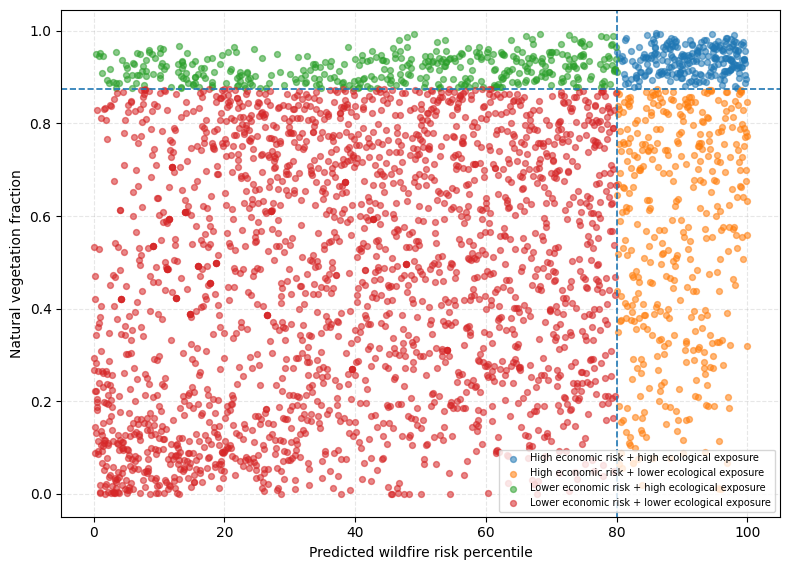

In [7]:

# ============================================================
# Cell 7 — Export Figure 1: Economic–ecological quadrant scatter
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5.8))

for quadrant, group in risk_df.groupby("economic_ecological_quadrant"):
    ax.scatter(
        group["predicted_risk_percentile"],
        group["natural_vegetation_fraction"],
        alpha=0.55,
        s=18,
        label=quadrant
    )

ax.axvline(economic_threshold, linestyle="--", linewidth=1.2)
ax.axhline(vegetation_threshold, linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted wildfire risk percentile")
ax.set_ylabel("Natural vegetation fraction")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(fontsize=7, loc="best")
plt.tight_layout()

save_current_figure(
    fig,
    "figure_1_economic_ecological_quadrant_scatter.pdf",
    "figure_1_economic_ecological_quadrant_scatter.png"
)
plt.show()


Saved figure PDF: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/figure_2_counties_by_risk_overlap_quadrant.pdf
Saved figure PNG: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/figure_2_counties_by_risk_overlap_quadrant.png


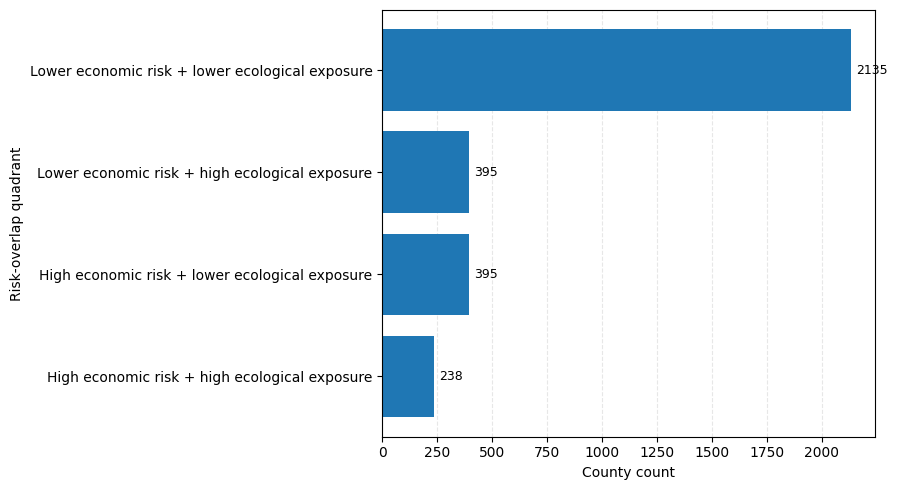

In [8]:

# ============================================================
# Cell 8 — Export Figure 2: County counts by quadrant
# ============================================================
count_df = risk_df["economic_ecological_quadrant"].value_counts().reindex([
    "High economic risk + high ecological exposure",
    "High economic risk + lower ecological exposure",
    "Lower economic risk + high ecological exposure",
    "Lower economic risk + lower ecological exposure"
]).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(count_df.index, count_df.values)
ax.set_xlabel("County count")
ax.set_ylabel("Risk-overlap quadrant")
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

for i, value in enumerate(count_df.values):
    ax.text(value + max(count_df.values) * 0.01, i, f"{int(value)}", va="center", fontsize=9)

plt.tight_layout()

save_current_figure(
    fig,
    "figure_2_counties_by_risk_overlap_quadrant.pdf",
    "figure_2_counties_by_risk_overlap_quadrant.png"
)
plt.show()


In [9]:

# ============================================================
# Cell 9 — Save full economic–ecological overlap dataset
# ============================================================
full_out = EXPORT_DIR / "county_economic_ecological_overlap_full.csv"
risk_df.to_csv(full_out, index=False)
print("Saved full overlap dataset:", full_out)
print("Rows:", len(risk_df), "Columns:", len(risk_df.columns))


Saved full overlap dataset: /content/thesis_exports/notebook8_economic_ecological_overlap_no_titles/county_economic_ecological_overlap_full.csv
Rows: 3163 Columns: 42
